In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install -q datasets transformers


In [3]:
!pip install -q huggingface_hub pandas torch

from huggingface_hub import snapshot_download
import pandas as pd
import glob
import os
import re
import torch
from torch.utils.data import Dataset, DataLoader

# 1. Download the raw CSV files directly (matching the 'data/' folder structure you found)
repo_path = snapshot_download(
    repo_id="BreathSense/BreathSense",
    repo_type="dataset",
    allow_patterns="data/**/*drmusic.csv"
)

# 2. Locate and process files into a dictionary
all_files = glob.glob(f"{repo_path}/data/**/*drmusic.csv", recursive=True)
data_dict = {}

for file_path in all_files:
    activity = os.path.basename(os.path.dirname(file_path))
    filename = os.path.basename(file_path)
    
    # Extract the p1, p2, etc. identifier
    match = re.search(r'(p\d+)', filename, re.IGNORECASE)
    if match:
        person_id = match.group(1).lower()
    else:
        continue 
        
    df = pd.read_csv(file_path)
    sequential_data = df.to_dict(orient='records')
    
    if person_id not in data_dict:
        data_dict[person_id] = {}
        
    data_dict[person_id][activity] = sequential_data

# 3. Build the 108-row DataFrame
final_df = pd.DataFrame.from_dict(data_dict, orient='index')
desired_columns = ['rest', 'walk', 'run', 'stairs']
existing_columns = [col for col in desired_columns if col in final_df.columns]
final_df = final_df[existing_columns]

# Sort numerically to ensure p1 to p108 order
final_df = final_df.loc[
    sorted(final_df.index, key=lambda x: int(x.replace('p', '')))
]

print(f"Data Reshaped! Total Unique People: {len(final_df)}")

# 4. PyTorch Dataset & DataLoader Integration
class UniformBreathSenseDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe
        
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Convert list of dictionaries into 2D lists
        rest_data = [list(step.values()) for step in row['rest']] if type(row['rest']) == list else []
        walk_data = [list(step.values()) for step in row['walk']] if type(row['walk']) == list else []
        run_data  = [list(step.values()) for step in row['run']] if type(row['run']) == list else []
        stairs_data = [list(step.values()) for step in row['stairs']] if type(row['stairs']) == list else []
        
        # Convert to tensors
        rest_tensor = torch.tensor(rest_data).float()
        walk_tensor = torch.tensor(walk_data).float()
        run_tensor  = torch.tensor(run_data).float()
        stairs_tensor = torch.tensor(stairs_data).float()
        
        return rest_tensor, walk_tensor, run_tensor, stairs_tensor

# Initialize your final DataLoader
train_dataset = UniformBreathSenseDataset(final_df)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# Verify the tensor shapes output by the DataLoader
for rest, walk, run, stairs in train_loader:
    print(f"Batch Ready! Rest Tensor Shape: {rest.shape}")
    break # Stops after printing the first batch

Fetching ... files: 0it [00:00, ?it/s]

Data Reshaped! Total Unique People: 108
Batch Ready! Rest Tensor Shape: torch.Size([16, 300, 1])


In [4]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# 1. Grab the entire dataset in one single batch (108 people)
# We set shuffle=False to keep p1 to p108 in perfect order
full_loader = DataLoader(train_dataset, batch_size=len(train_dataset), shuffle=False)
rest, walk, run, stairs = next(iter(full_loader))

# Convert PyTorch tensors to Numpy arrays and remove the empty last dimension
# Shape goes from (108, 300, 1) to (108, 300)
rest_np = rest.squeeze(-1).numpy()
walk_np = walk.squeeze(-1).numpy()
run_np = run.squeeze(-1).numpy()
stairs_np = stairs.squeeze(-1).numpy()

# 2. The "Shallow" Feature Engineering Step
# We extract Mean, Standard Deviation, Max, and Min for every person's 300 steps
def extract_stats(data):
    means = np.mean(data, axis=1)
    stds = np.std(data, axis=1)
    maxes = np.max(data, axis=1)
    mins = np.min(data, axis=1)
    # Combine into a single matrix of features
    return np.column_stack((means, stds, maxes, mins))

print("Extracting statistical features...")
f_rest = extract_stats(rest_np)
f_walk = extract_stats(walk_np)
f_run = extract_stats(run_np)
f_stairs = extract_stats(stairs_np)

# Glue all 4 activities together. 
# 4 features * 4 activities = 16 total features per person
X_shallow = np.hstack((f_rest, f_walk, f_run, f_stairs))
print(f"Shallow Feature Matrix Shape: {X_shallow.shape}") # Should be (108, 16)

# 3. Scaling (Crucial for traditional K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_shallow)

# 4. K-Means Clustering
kmeans_shallow = KMeans(n_clusters=2, random_state=42, n_init=10)
shallow_labels = kmeans_shallow.fit_predict(X_scaled)

# Add to your dataframe to compare later
final_df['Shallow_Cluster'] = shallow_labels

Extracting statistical features...
Shallow Feature Matrix Shape: (108, 16)


In [5]:
import torch
from torch.utils.data import Subset, DataLoader

# 1. Find the literal row numbers for anyone where the ID number is <= 90
male_indices = []

for row_number, person_id in enumerate(final_df.index):
    # Extract the integer from the string (e.g., 'p45' becomes 45)
    id_number = int(person_id.replace('p', ''))
    
    # If they are p1 through p90, save their row number
    if id_number <= 90:
        male_indices.append(row_number)

print(f"Total Male Participants Found: {len(male_indices)}") 
# This should print 90!

# 2. Filter your master DataFrame so we can save the labels later
# .iloc[] isolates rows based on their numerical position
male_df = final_df.iloc[male_indices].copy()

# 3. Create the PyTorch Subset using those exact same row numbers
male_dataset = Subset(train_dataset, male_indices)

# 4. Create new DataLoaders exclusively for the male data
male_train_loader = DataLoader(male_dataset, batch_size=16, shuffle=True)
male_extract_loader = DataLoader(male_dataset, batch_size=16, shuffle=False)

Total Male Participants Found: 90


Initializing Autoencoder Training...
Epoch [1/15], Reconstruction Loss: 1.7758
Epoch [2/15], Reconstruction Loss: 1.7661
Epoch [3/15], Reconstruction Loss: 1.7461
Epoch [4/15], Reconstruction Loss: 1.7495
Epoch [5/15], Reconstruction Loss: 1.7282
Epoch [6/15], Reconstruction Loss: 1.7325
Epoch [7/15], Reconstruction Loss: 1.7286
Epoch [8/15], Reconstruction Loss: 1.7307
Epoch [9/15], Reconstruction Loss: 1.7363
Epoch [10/15], Reconstruction Loss: 1.7291
Epoch [11/15], Reconstruction Loss: 1.7480
Epoch [12/15], Reconstruction Loss: 1.7122
Epoch [13/15], Reconstruction Loss: 1.7379
Epoch [14/15], Reconstruction Loss: 1.7385
Epoch [15/15], Reconstruction Loss: 1.7086

Extracting Latent Representations...
Extraction Complete. Feature Matrix Shape: (90, 32)

Running K-Means and PCA...


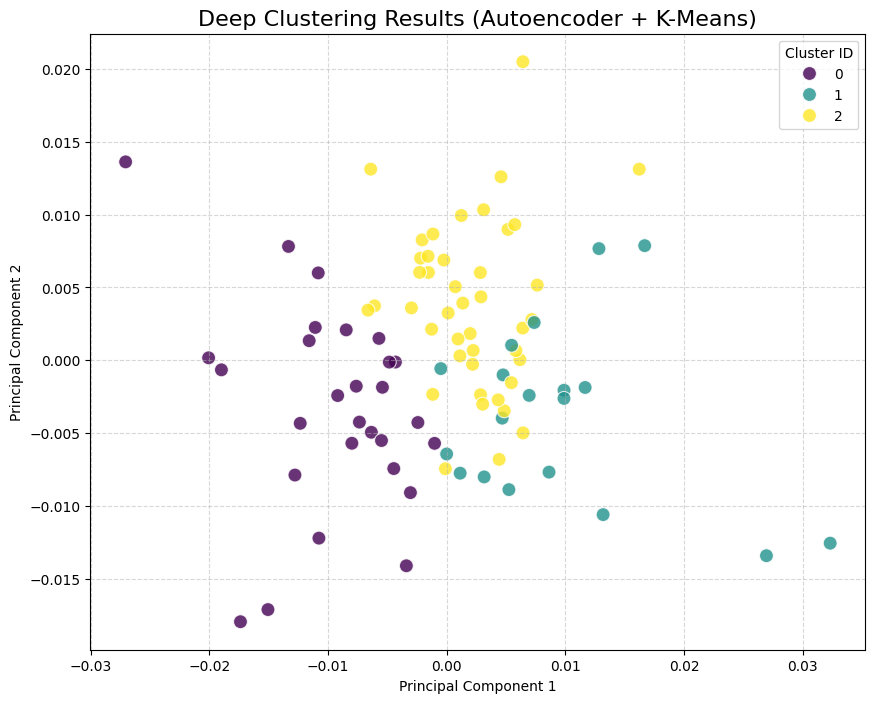


First 10 Cluster Assignments:
p1     2
p2     2
p3     2
p4     0
p5     0
p6     2
p7     1
p8     0
p9     1
p10    2
Name: Male_Deep_Cluster, dtype: int32


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader

# ==========================================
# 1. DEFINE THE AUTOENCODER
# ==========================================
class MultiActivityAutoencoder(nn.Module):
    def __init__(self, seq_len=300, input_size=1, hidden_size=64, latent_dim=32):
        super(MultiActivityAutoencoder, self).__init__()
        self.seq_len = seq_len
        self.hidden_size = hidden_size
        
        # ENCODER
        self.encoder_lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.fc_encode = nn.Linear(hidden_size * 4, latent_dim) 
        
        # DECODER
        self.fc_decode = nn.Linear(latent_dim, hidden_size * 4)
        self.decoder_lstm = nn.LSTM(input_size=hidden_size, hidden_size=input_size, batch_first=True)
        
    def forward(self, rest, walk, run, stairs):
        # Encode all 4 activities
        _, (h_rest, _) = self.encoder_lstm(rest)
        _, (h_walk, _) = self.encoder_lstm(walk)
        _, (h_run, _)  = self.encoder_lstm(run)
        _, (h_stairs, _) = self.encoder_lstm(stairs)
        
        # Combine hidden states and compress to latent vector
        h_combined = torch.cat((h_rest.squeeze(0), h_walk.squeeze(0), h_run.squeeze(0), h_stairs.squeeze(0)), dim=1)
        latent_vector = self.fc_encode(h_combined) 
        
        # Decode the latent vector
        decoded_hidden = self.fc_decode(latent_vector)
        h1, h2, h3, h4 = torch.split(decoded_hidden, self.hidden_size, dim=1)
        
        # Expand across the 300 time-steps
        r1 = h1.unsqueeze(1).repeat(1, self.seq_len, 1)
        r2 = h2.unsqueeze(1).repeat(1, self.seq_len, 1)
        r3 = h3.unsqueeze(1).repeat(1, self.seq_len, 1)
        r4 = h4.unsqueeze(1).repeat(1, self.seq_len, 1)
        
        # Reconstruct the original 300-step sequences
        out_rest, _ = self.decoder_lstm(r1)
        out_walk, _ = self.decoder_lstm(r2)
        out_run, _ = self.decoder_lstm(r3)
        out_stairs, _ = self.decoder_lstm(r4)
        
        return out_rest, out_walk, out_run, out_stairs, latent_vector

# ==========================================
# 2. TRAIN THE AUTOENCODER (UNSUPERVISED)
# ==========================================
print("Initializing Autoencoder Training...")

model = MultiActivityAutoencoder(seq_len=300, input_size=1, hidden_size=64, latent_dim=32)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss() 

num_epochs = 15

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for batch_idx, (rest, walk, run, stairs) in enumerate(male_train_loader):
        optimizer.zero_grad()
        
        # Forward pass
        out_rest, out_walk, out_run, out_stairs, _ = model(rest, walk, run, stairs)
        
        # Calculate reconstruction error for all 4 tensors
        loss = (criterion(out_rest, rest) + 
                criterion(out_walk, walk) + 
                criterion(out_run, run) + 
                criterion(out_stairs, stairs))
        
        # Backward pass
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
    epoch_loss = running_loss / len(male_train_loader)
    print(f'Epoch [{epoch+1}/{num_epochs}], Reconstruction Loss: {epoch_loss:.4f}')

# ==========================================
# 3. EXTRACT LATENT VECTORS (THE FEATURES)
# ==========================================
print("\nExtracting Latent Representations...")

# We use a new loader with shuffle=False to keep p1 to p108 in exact order
extraction_loader = DataLoader(male_dataset, batch_size=16, shuffle=False)
model.eval()
latent_representations = []

with torch.no_grad():
    for rest, walk, run, stairs in extraction_loader:
        _, _, _, _, latent_vector = model(rest, walk, run, stairs)
        latent_representations.append(latent_vector)

# Shape becomes (108, 32)
X_encoded = torch.cat(latent_representations, dim=0).numpy()
print(f"Extraction Complete. Feature Matrix Shape: {X_encoded.shape}")

# ==========================================
# 4. K-MEANS CLUSTERING & VISUALIZATION
# ==========================================
print("\nRunning K-Means and PCA...")

# Fit K-Means
num_clusters = 3  # Adjust this if you expect a different number of groups
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_encoded)

# Save labels back to your original DataFrame
male_df['Male_Deep_Cluster'] = cluster_labels

# PCA to reduce 32 dimensions to 2 for plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_encoded)

# Plotting the results
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_pca[:, 0], 
    y=X_pca[:, 1], 
    hue=cluster_labels, 
    palette='viridis', 
    s=100, 
    alpha=0.8
)

plt.title('Deep Clustering Results (Autoencoder + K-Means)', fontsize=16)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster ID')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Display the first few cluster assignments
print("\nFirst 10 Cluster Assignments:")
print(male_df['Male_Deep_Cluster'].head(10))

In [7]:
print("--- DEEP CLUSTERING (MALES ONLY) ---\n")

# Iterate through each of the 3 clusters generated by the Autoencoder
for cluster_id in range(3):
    # Extract the index (the p1, p2, p3 labels) for everyone in this specific deep cluster
    people = male_df[male_df['Male_Deep_Cluster'] == cluster_id].index.tolist()
    
    # Print the results cleanly
    print(f"========== MALE DEEP CLASS {cluster_id} ==========")
    print(f"Total Participants: {len(people)}")
    print(f"Participants: {', '.join(people)}\n")

--- DEEP CLUSTERING (MALES ONLY) ---

========== MALE DEEP CLASS 0 ==========
Total Participants: 28
Participants: p4, p5, p8, p12, p13, p14, p21, p23, p24, p29, p30, p36, p45, p47, p48, p49, p51, p54, p59, p66, p70, p71, p73, p74, p75, p87, p88, p89

========== MALE DEEP CLASS 1 ==========
Total Participants: 19
Participants: p7, p9, p17, p19, p22, p25, p26, p28, p32, p40, p43, p52, p56, p63, p69, p82, p83, p84, p90

========== MALE DEEP CLASS 2 ==========
Total Participants: 43
Participants: p1, p2, p3, p6, p10, p11, p15, p16, p18, p20, p27, p31, p33, p34, p35, p37, p38, p39, p41, p42, p44, p46, p50, p53, p55, p57, p58, p60, p61, p62, p64, p65, p67, p68, p72, p76, p77, p78, p79, p80, p81, p85, p86

